# Exercise 1 - Word Embeddings

In this exercise you will experiment with word embeddings and the spaces of word meanings. There are 4 sections in total and 13 questions (marked Q1-Q13). Once you finish the exercise, please submit the notebook along with your implementations, cell outputs, and answers to the questions. The notebook should be renamed as [last name]_sds2025_exercise1.ipynb and submitted through ILIAS.

In [4]:
%matplotlib inline
import os
import urllib.request
import gensim  
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import numpy as np

#### Q1: Name two advantages of using dense parametrised word representations compared to one-hot vectors

A: 
1. Dense embeddings have small fixed length which is good for memory efficiency compared to one-hot which has vector dimension equal to the vocabulary size (high dimensionality)
2. Dense embeddings have semantic similarity where similar words can cluster together because they have similar learned values, one-hot vectors does not caputre the relationship or similarities between words

## Section 1: Play around with pre-trained Word2Vec

Word2Vec was one of the first models that learned a dense word-vector representation. Let us start with a pretrained Word2Vec model.

#### Q2: What was the intuition about the Word2Vec training?

A: The intuition would be: words appearing in similar contexts have similar meanings

In [2]:
import gensim.downloader as api
corpus = api.load('text8')

from gensim.models.word2vec import Word2Vec
print("Loading model..")
w2v_pretrained = Word2Vec(corpus)
print("Finished loading.")

[==================================================] 100.0% 31.6/31.6MB downloaded
Loading model..


Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


Finished loading.


In [5]:
# Check the number of embedded words and their embedding size
w2v_pretrained.wv.vectors.shape

(71290, 100)

In [6]:
# Get the vector to a word
queen_vec = w2v_pretrained.wv['apple']
print(queen_vec)

[ 0.9027882   0.8102013   1.1022049   0.9964104  -0.86236924 -2.9124079
  0.3118968  -1.5653137  -2.571004   -0.73022944 -1.266333   -2.2051754
  3.004846   -2.8011024  -0.83505875  0.80128986  0.9976771   0.8702085
  3.0157583   1.2650512  -1.7197514   0.8935106  -0.09349314 -1.3736192
 -0.7281034   0.73576415  0.5850627  -1.7010406   0.05587496  0.40066716
 -0.06797605  1.6731532   0.31867176 -0.6307697   0.5332201  -0.93076974
  1.4778574  -1.3331771   1.1106546   1.0205232   1.2217238  -0.3478737
  0.00474801  0.7732385   0.34286365 -1.4211822  -0.2106834   0.28263015
  0.77541256 -1.6818023  -0.7719834   2.3364344   2.0402958   1.3974943
 -2.1461167   1.4357541   0.48352727 -0.25118458 -3.0341935  -2.2718835
 -1.2446074   1.2538059  -0.7372102  -0.86860263 -0.9341962  -1.2821679
 -1.3479854  -1.038006   -0.66081196  0.7828857   1.1917005  -0.02028036
  1.2024034   2.6826587   0.89599127 -0.9770813   1.9422293   1.9309152
 -1.5519291  -0.19739604 -1.067467    0.61831945  1.6742686 

We can use the cosine-smililarity metric to compare different embeddings. 

In [7]:
w2v_pretrained.wv.similarity('apple', 'orange')

np.float32(0.20258541)

or even find the most similar words to a given word

In [8]:
w2v_pretrained.wv.most_similar('apple')

[('macintosh', 0.7917056083679199),
 ('intel', 0.7156778573989868),
 ('ibm', 0.7150270342826843),
 ('amiga', 0.7144079208374023),
 ('atari', 0.6911924481391907),
 ('amd', 0.6710533499717712),
 ('microsoft', 0.6690640449523926),
 ('hypercard', 0.6638991236686707),
 ('intellivision', 0.6612188220024109),
 ('mac', 0.6588789820671082)]

Find interesting relationships between words: A is to B as C is to ? 


In [9]:
w2v_pretrained.wv.most_similar(positive=['man', 'queen'], negative=['king'])

[('woman', 0.7218824625015259),
 ('girl', 0.6439687609672546),
 ('lady', 0.5803619623184204),
 ('beauty', 0.5609505772590637),
 ('blonde', 0.5606364011764526),
 ('boy', 0.5595908761024475),
 ('gentleman', 0.5527994632720947),
 ('bride', 0.5480024814605713),
 ('creature', 0.5456311106681824),
 ('soul', 0.5358976721763611)]

In [10]:
w2v_pretrained.wv.most_similar(positive=['ocean', 'bee'], negative=['fish'])

[('crater', 0.513935387134552),
 ('hacho', 0.49399662017822266),
 ('strait', 0.4920130968093872),
 ('trail', 0.486541748046875),
 ('challenger', 0.4847249686717987),
 ('ecliptic', 0.48363345861434937),
 ('spaceship', 0.47552919387817383),
 ('stabilising', 0.4707927405834198),
 ('glacier', 0.4686860144138336),
 ('trench', 0.46526864171028137)]

In [11]:
# Q3: Given a word 'w' and a list of words, find the word in the list that is most similar to 'w' 

def most_similar_to_given(w, word_list):
    most_similar = None
    highest_similarity = -1
    for word in word_list:
        similarity = w2v_pretrained.wv.similarity(w, word)
        if similarity > highest_similarity:
            highest_similarity = similarity
            most_similar = word
    return most_similar

In [12]:
# Q4: Find the most similar word to apple in the list
word = 'apple'
candidates = ['fruit', 'chair', 'mountain', 'freedom']
print(most_similar_to_given(word, candidates))

fruit


In [13]:
# Q5: Try again. 
word = 'apple'
candidates = ['fruit', 'chair', 'computer', 'freedom']
print(most_similar_to_given(word, candidates))

computer


#### Q6: What is an issue that the two examples reveal?

Answer:
If the word has two meanings, Word2Vec doesn't represent different meaning it only averages both meaning
and if a word like "Computer" appears it will score higher similarity sense in text8 corpus there are many occurrences of Apple as a company with computer meaning

How can we extend the concept of embedding from word level to sentence level? One way is to consider the average word embeddings as the sentence embedding. The sentence embedding allows us to compare sentences.

In [14]:
from sklearn.metrics.pairwise import cosine_similarity
from copy import deepcopy

#Q7: Generalize the similarity function to be able to compare sentences using cosine-similarity

def sentence_similarity(embeddings, sentence1, sentence2):
    # Accept either sentence strings or pre-tokenized sequences.
    def tokenize(sentence):
        if isinstance(sentence, str):
            return sentence.lower().split()
        return [str(token).lower() for token in sentence]

    vectors1 = [embeddings[word] for word in tokenize(sentence1) if word in embeddings]
    vectors2 = [embeddings[word] for word in tokenize(sentence2) if word in embeddings]
    if not vectors1 or not vectors2:
        raise ValueError("Each sentence must contain at least one in-vocabulary word.")

    avg_vec1 = np.mean(vectors1, axis=0)
    avg_vec2 = np.mean(vectors2, axis=0)
    return cosine_similarity([avg_vec1], [avg_vec2])[0][0]

In [15]:
print(sentence_similarity(w2v_pretrained.wv, 'apple is more tasty than orange', 'fruit'))
print(sentence_similarity(w2v_pretrained.wv, 'apple is more tasty than orange', 'computer'))

0.2958507
0.28338745


#### Q8: The similarity changes but is still close to the other. Why is that?

A: With word-level tokenization, the sentence is slightly more similar to *fruit* (0.296) than to *computer* (0.283), but the difference is small. Mean pooling treats a sentence as a bag of words: it loses word order and compositional meaning, while frequent words such as *is*, *more*, and *than* dilute the informative words. A contextual sentence encoder would represent this meaning more clearly.

## Section 2: Train Word2Vec model using Gensim

Now it is time to train our own word-embeddings. We will use the DSTC2 data to train our models. This data set consists of dialogues where a customer tries to find information about restaurants. You will need to adjust some hyperparameters of the training in order to get meaningful clusters in the word embedding space.

In [16]:
# read data
import json

with open("dstc2_utterances", 'rb') as data_file:
    pre_data = json.load(data_file)

data = []
# normalize and tokenize per word
for sentence in pre_data:
    data.append(sentence.lower().split(' '))

In [17]:
from gensim.models import Word2Vec
# Train your model using the Word2Vec class. Remember to adjust the hyperparameters to get a meaningful word embeddings space.
trained_w2v = Word2Vec(data, vector_size=300, window=3, min_count=1, epochs=1000)

In [18]:
# To check whether your embeddings are useful, perform the sanity check here

# South, east, centre and north should be similar to west
print(trained_w2v.wv.most_similar('west', topn=5))

# cheap, expensive should be similar to moderate
print(trained_w2v.wv.most_similar('moderate', topn=5))

[('south', 0.8970180153846741), ('east', 0.8642281293869019), ('north', 0.8309629559516907), ('centre', 0.677800714969635), ('alimentum', 0.40511512756347656)]
[('expensive', 0.5440605282783508), ('cheap', 0.5210354924201965), ('are', 0.2957089841365814), ('the', 0.28569310903549194), ('indian', 0.2762314975261688)]


In [19]:
#convenience function for plotting embeddings into 2-dimensional space

def plot_word_embeddings(model, search_list):
    words = []
    cluster_labels = []  # Track which cluster each word belongs to
    colors = ['red', 'blue', 'green', 'purple', 'orange', 'brown', 'pink', 'gray', 'olive', 'cyan']
    
    for i, term in enumerate(search_list):
        similar_words = [w[0] for w in model.wv.most_similar([term], topn=5)]
        words += similar_words
        cluster_labels += [i] * len(similar_words)  # Assign cluster color index
    
    # Add search terms themselves with distinct cluster indices
    words += search_list
    cluster_labels += list(range(len(search_list)))  # Each search term gets its own color
    
    print("Words plotted:", words)
    print("Cluster assignments:", cluster_labels)

    vectors = model.wv[words]
    print("Shape:", vectors.shape)

    tsne = TSNE(n_components=2, random_state=0, max_iter=10000, perplexity=7)
    T = tsne.fit_transform(vectors)

    plt.figure(figsize=(16, 10))
    
    # Plot each cluster with different colors
    for i, term in enumerate(search_list):
        cluster_indices = [j for j, label in enumerate(cluster_labels) if label == i]
        cluster_words = [words[j] for j in cluster_indices]
        cluster_T = T[cluster_indices]
        
        color = colors[i % len(colors)]
        plt.scatter(cluster_T[:, 0], cluster_T[:, 1], c=color, label=term, s=100, alpha=0.7)
        
        # Annotate each point
        for j, (label, x, y) in enumerate(zip(cluster_words, cluster_T[:, 0], cluster_T[:, 1])):
            plt.annotate(label, xy=(x, y), xytext=(5, 5), textcoords='offset points', 
                        fontsize=10, bbox=dict(boxstyle='round,pad=0.3', facecolor=color, alpha=0.3))
    
    plt.legend(title="Search Terms", loc='best')
    plt.title("Word Embeddings Clusters")
    plt.xlabel("t-SNE Dimension 1")
    plt.ylabel("t-SNE Dimension 2")
    plt.grid(True, alpha=0.3)
    plt.show()

Words plotted: ['expensive', 'moderate', 'are', 'confirm', 'priced', 'south', 'east', 'north', 'centre', 'alimentum', 'vietnamese', 'thai', 'turkish', 'basque', 'german', 'cheap', 'west', 'italian']
Cluster assignments: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 0, 1, 2]
Shape: (18, 300)


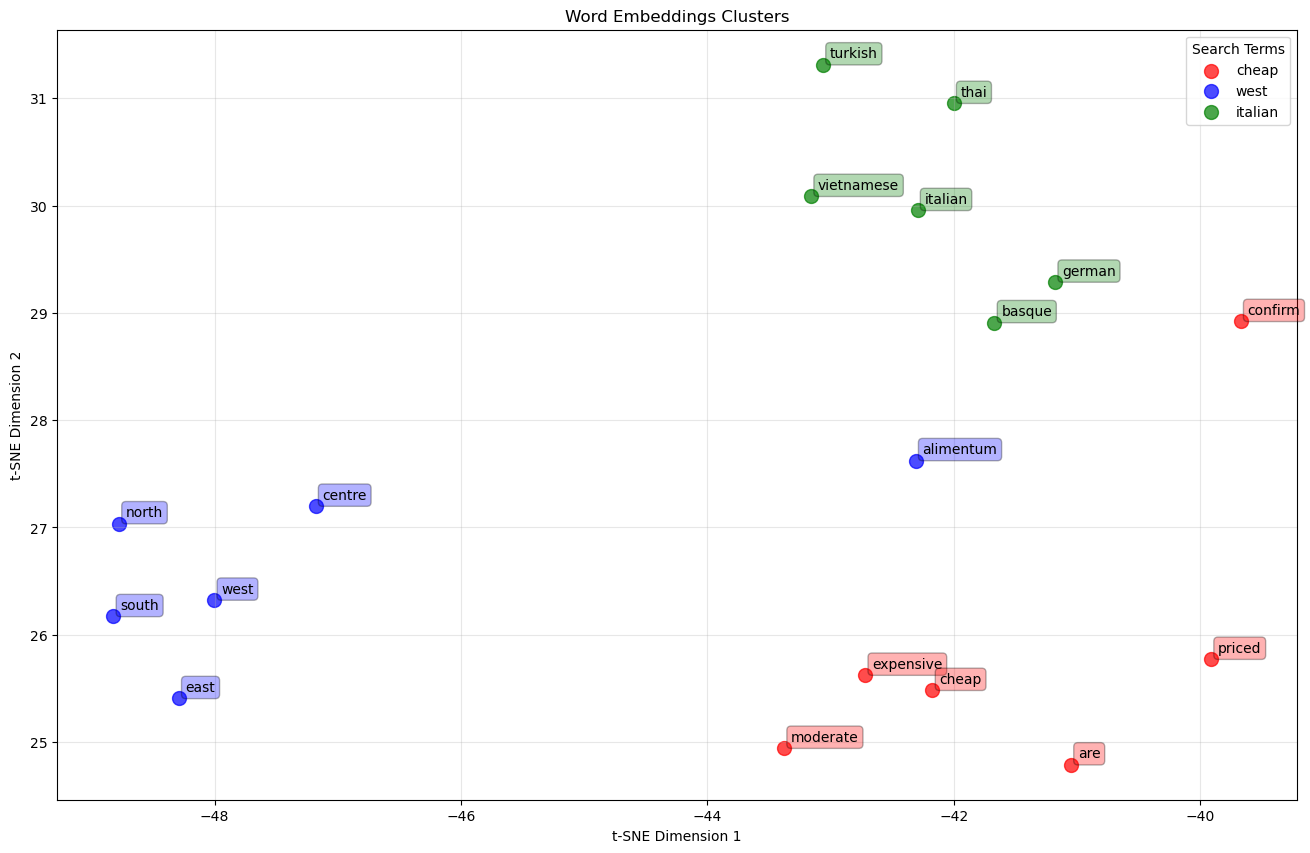

In [20]:
#plot to see clustering. You should be able to identify three clusters. 
search_list = ['cheap', 'west', 'italian']
plot_word_embeddings(trained_w2v, search_list)

#### Q9: If you have a neural network that needs to make predictions on these words, can these embeddings and clusters provide an advantage? How?

A: Feeding word embeddings directly to NN as features will help NN to capture numerical features and relationships between words

## Section 3: Train FastText model using Gensim

A big issue of Word2Vec is the fixed vocabulary size, an alternative solution is provided by FastText

In [21]:
# not in the vocabulary
try:
    trained_w2v.wv.most_similar('inexpensive')
except KeyError:
    print("Error: This word is not in the vocabulary!")

Error: This word is not in the vocabulary!


In [22]:
from gensim.models.fasttext import FastText
#Train your FastText model using the FastText method
trained_ft = FastText(vector_size=100, window=5, min_count=1, sentences=data, epochs=1000)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [23]:
#Sanity check if trained word-embeddings capture similarities as before
print(trained_ft.wv.most_similar('west'))
print(trained_ft.wv.most_similar('moderate'))

[('south', 0.8573727011680603), ('east', 0.8245607614517212), ('north', 0.7589028477668762), ('eastern', 0.6760517358779907), ('centre', 0.5852594971656799), ('alimentum', 0.4818018674850464), ('northampton', 0.4026281237602234), ('request', 0.37279951572418213), ('ditton', 0.3378696143627167), ('wok', 0.31574344635009766)]
[('modern', 0.7436770796775818), ('moderately', 0.6597340106964111), ('expensive', 0.5262137651443481), ('cheap', 0.4819817841053009), ('give', 0.41760462522506714), ('indian', 0.41642796993255615), ('italian', 0.3275678753852844), ('european', 0.3267752528190613), ('international', 0.3093608319759369), ('steakhouse', 0.29154008626937866)]


Words plotted: ['expensive', 'moderate', 'moderately', 'modern', 'give', 'south', 'east', 'north', 'eastern', 'centre', 'indian', 'mean', 'thai', 'turkish', 'persian', 'cheap', 'west', 'italian']
Cluster assignments: [0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 2, 2, 2, 2, 2, 0, 1, 2]
Shape: (18, 100)


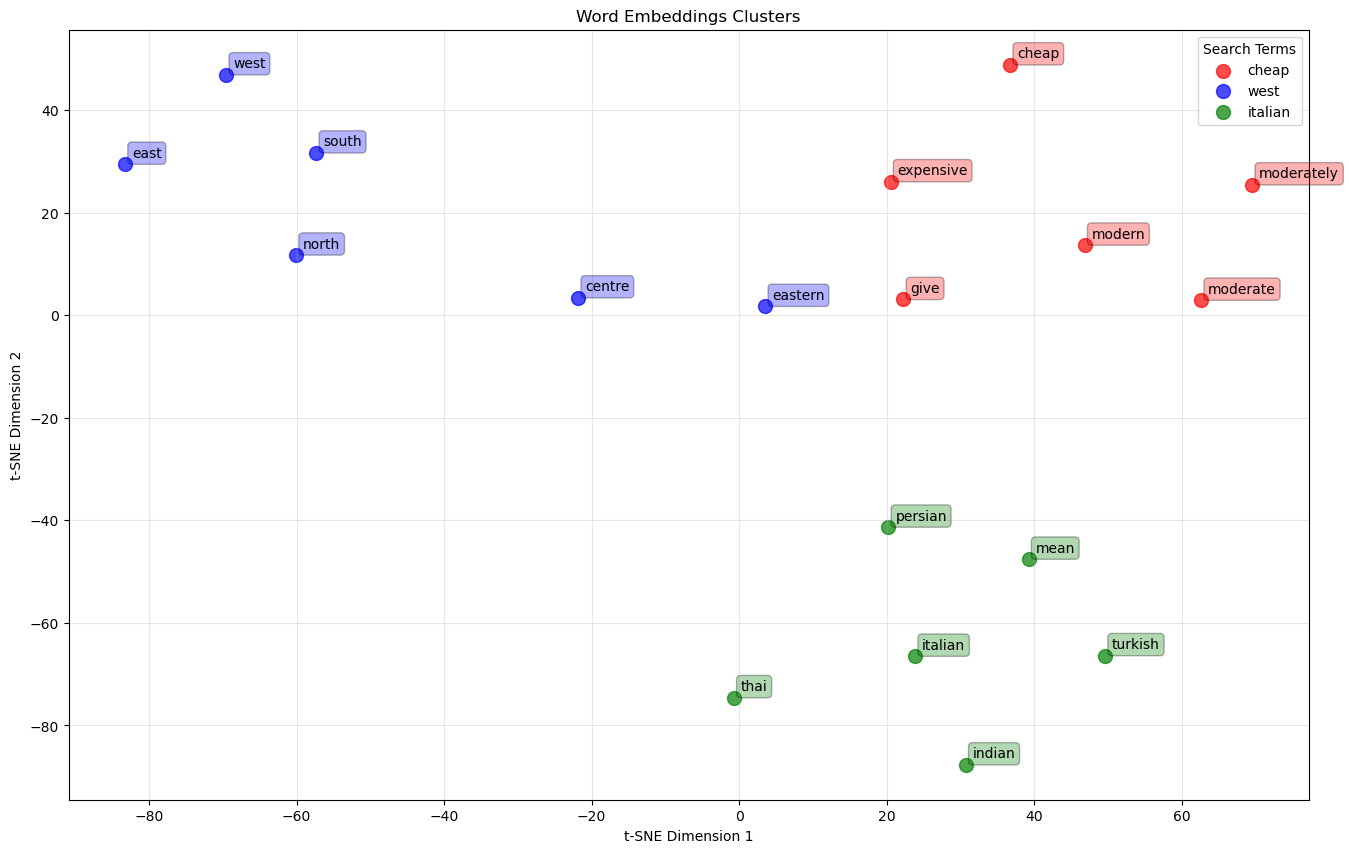

In [24]:
search_list = ['cheap', 'west', 'italian']
plot_word_embeddings(trained_ft, search_list)

In [25]:
#FastText lets us do comparisons for words outside of the vocabulary in contrast to Word2Vec
trained_ft.wv.most_similar('inexpensive')

[('expensive', 0.9913408160209656),
 ('give', 0.5896074771881104),
 ('moderate', 0.5469754934310913),
 ('cheap', 0.48994630575180054),
 ('international', 0.4194811284542084),
 ('modern', 0.4080600142478943),
 ('indian', 0.39835551381111145),
 ('spanish', 0.374757319688797),
 ('chinese', 0.370736300945282),
 ('restaurant', 0.35873353481292725)]

#### Q10: If you look at the last print, what might be problematic for a classifier that needs to detect the user preferences, such as food-type, location, etc?

Answer: FastText can create a vector for the unseen word *inexpensive*, but it ranks *expensive* as its closest neighbour even though the two words express opposite price preferences. Their high similarity is driven partly by shared character n-grams. A classifier that relies on these embeddings may therefore confuse preference values or categories when words look similar but have different meanings.


## Section 4: Train your own Word2Vec model

In this last section, we will implement the simplest version of the SkipGram Word2Vec model and train it using the DSTC data that we already used to train a Word2Vec model with gensim.

In order to do that, we need to perform the following steps:

1. We need to create a vocabulary dictionary that maps every word in the data to an index.
2. We need to create the data set for the Word2Vec model: The data set consists of pairs (x,y), where x is a word in a sentence and y is a word in the context of x. y is in the context of x if and only if y is in the window of x, where the size of the window is a hyperparameter (set to 5 in the code). x is not in the context of itself. As an example: "i need something in the expensive price range" with window-size of 2: --> (i, need), (i, something), (need, i), (need, something), (need, in), ...
3. Build the model: The model has a learnable embedding matrix U of size (vocabulary_size, embedding_dim) and another learnable matrix W of size (embedding_dim, vocabulary_size). The goal of the model is to maximise the log-likelihood of y given x, for all pairs (x, y) in the data. To do that, you should preprocess the data so that the pairs (x, y) are the indices of the words and not the string representation. The model then maps the index of x to the corresponding row of the embedding matrix U, yielding a vector v of size embedding_dim. We then do a matrix multiplication (i.e. a linear layer without bias) v*W to output a vector of size vocabulary_size. Afterwards, we apply a softmax-function to obtain a probability distribution over the vocabulary. We then need to maximise the probability of y.

Comments: Feel free to use the library of your choice (tensorflow, keras, pytorch..). You can use existing methods like embedding-layers or linear layers to build your model.

You can find illustrations of the data set creation and model architecture below (taken from http://mccormickml.com/2016/04/19/word2vec-tutorial-the-skip-gram-model/)

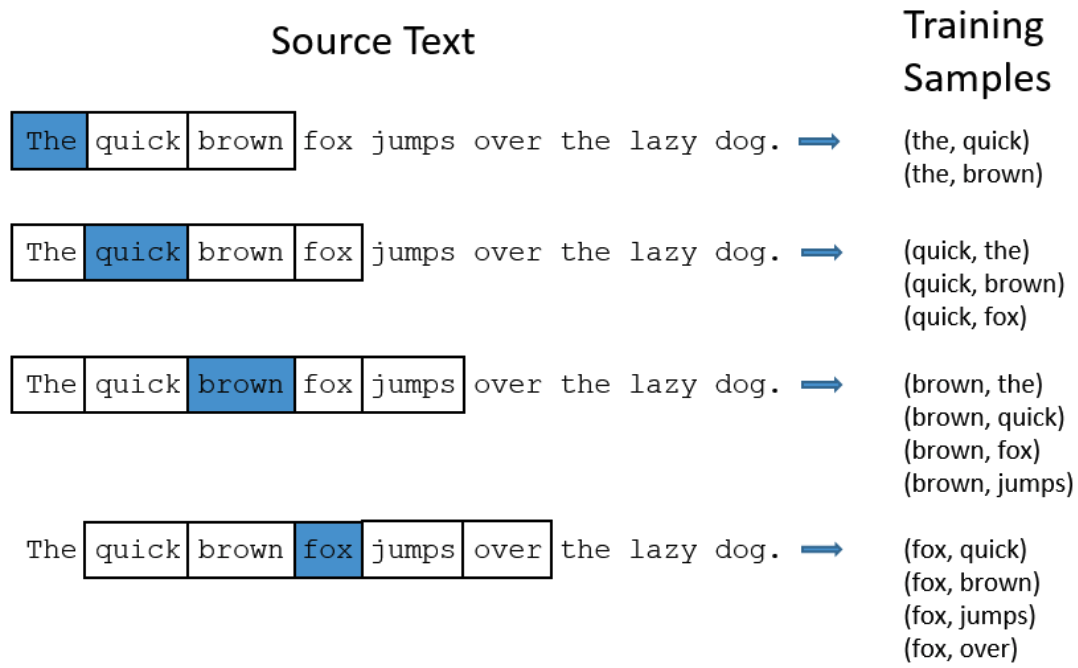

In [26]:
from IPython.display import Image
Image("data_creation.png")

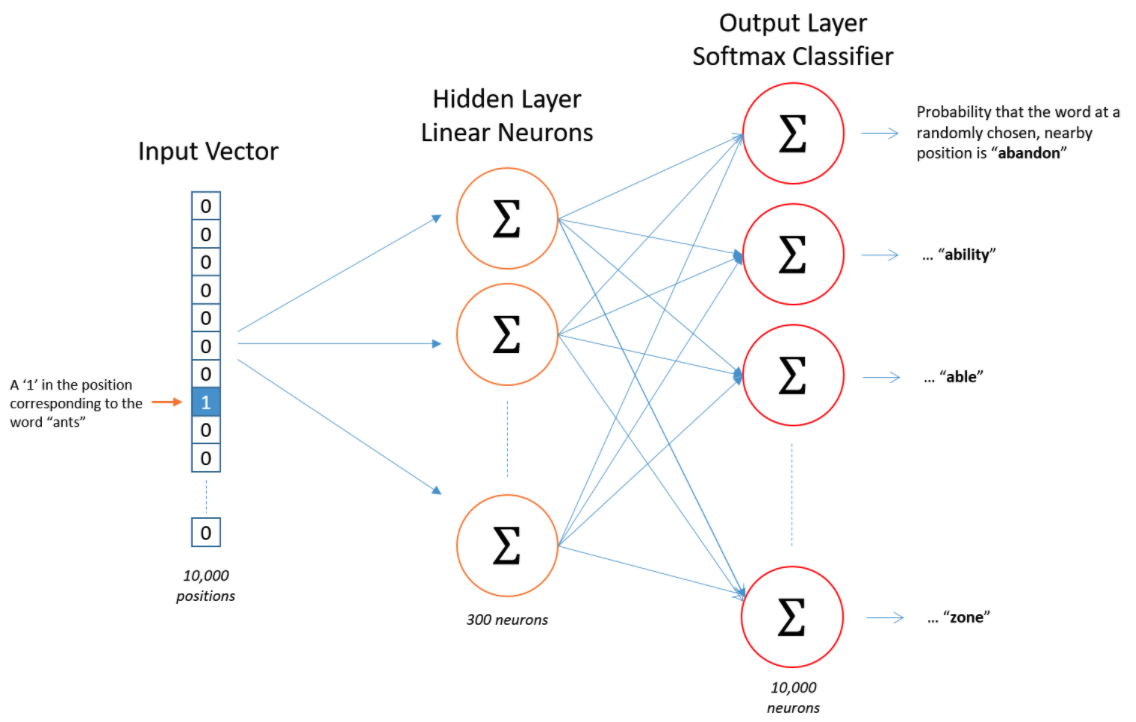

In [27]:
Image("word2vec_model.png")

In [3]:
# Import packages if you need more
from torch import nn
import torch.optim as optim
import numpy as np
import torch

#### Step 1

In [29]:
# Q11: create two dictionaries word2idx and idx2word that gives each word an index

tokenized_corpus = data
word2idx = {}
idx2word = {}
idx = 0
for sentence in tokenized_corpus:
    for word in sentence:
        if word not in word2idx:
            word2idx[word] = idx
            idx2word[idx] = word
            idx += 1

#### Step 2

In [ ]:
# create the data set here, consisting of pairs (word, context-word)

window_size = 5    # the size of the context window
idx_pairs = []     # this will be the data set, containing pairs (word, context-word)

#Q12: Fill your data set idx_pairs here, it should be a np-array
for sentence in tokenized_corpus:
    for i, word in enumerate(sentence):
        for j in range(max(0, i - window_size), min(len(sentence), i + window_size + 1)):
            if j != i:
                idx_pairs.append((word2idx[word], word2idx[sentence[j]]))

# Convert to numpy array
idx_pairs = np.array(idx_pairs)

#### Step 3

In [31]:
# Build the model here, use the libraries of your choice, such as torch, tensorflow, keras 
# and methods such as embedding layers or linear layers, etc.

class SkipGram(nn.Module):
    #Q13: Add your word2vec model here
    def __init__(self, vocab_size, embedding_dim):
        super(SkipGram, self).__init__()
        self.embeddings = nn.Embedding(vocab_size, embedding_dim)
        self.output_layer = nn.Linear(embedding_dim, vocab_size)
        
    def forward(self, input_word):
        embedded = self.embeddings(input_word)
        output = self.output_layer(embedded)
        return output

In [ ]:
num_epochs = 100
embedding_dim = 100
learning_rate = 0.003
batch_size = 128
vocabulary_size = len(word2idx)
criterion = nn.CrossEntropyLoss()

model = SkipGram(vocabulary_size, embedding_dim)
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

for epoch in range(num_epochs):
    
    training_indices = np.arange(idx_pairs.shape[0])
    np.random.shuffle(training_indices)
    
    X_train = idx_pairs[training_indices][:, 0]
    Y_train = idx_pairs[training_indices][:, 1]
    
    n_batches = X_train.shape[0]//batch_size
    total_loss = 0
    for i in range(n_batches):
        
        X_batch = X_train[i * batch_size: (i+1) * batch_size]
        Y_batch = Y_train[i * batch_size: (i+1) * batch_size]
        
        # Convert to tensors
        X_batch = torch.LongTensor(X_batch)
        Y_batch = torch.LongTensor(Y_batch)
        
        # Optimisation step
        optimizer.zero_grad()
        output = model(X_batch)
        loss = criterion(output, Y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, total loss:", total_loss / n_batches)

Epoch 0, total loss: 4.2330139636993405
Epoch 10, total loss: 3.412675402714656
Epoch 20, total loss: 3.38952702323159
Epoch 30, total loss: 3.3800109250204904
Epoch 40, total loss: 3.3729252637087646
Epoch 50, total loss: 3.3687268592499113
Epoch 60, total loss: 3.3655763814737507
Epoch 70, total loss: 3.3635778207045335
Epoch 80, total loss: 3.3610588037050686
Epoch 90, total loss: 3.360500657427442


After the training has finished, we want to see whether the created embeddings make sense. In order to do that, write a function that takes a word from the vocabulary as input and outputs the n most similar words, where similarity is measured by taking the learned word-embeddings and computing cosine-similarity.

In [ ]:
def find_most_similar(word, num_similar=3):
    if word not in word2idx:
        print(f"Word '{word}' not found in vocabulary.")
        return []

    word_idx = word2idx[word]
    word_embedding = model.embeddings.weight[word_idx]
    similarities = torch.cosine_similarity(word_embedding.unsqueeze(0), model.embeddings.weight, dim=1)
    similar_indices = torch.topk(similarities, k=num_similar + 1).indices[1:]  # Exclude the word itself
    similar_words = [idx2word[idx.item()] for idx in similar_indices]
    return similar_words

In [49]:
print(find_most_similar("cheap"))

['moderate', 'expensive', 'price']


In [37]:
find_most_similar("south")

['west', 'east', 'north']

In [38]:
find_most_similar("indian")

['turkish', 'mediterranean', 'thai']